In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("ev_project.db")
cursor = conn.cursor()

In [2]:
# Load the cleaned DataFrames
df_flat_cleaned = pd.read_pickle("df_flat_cleaned.pkl")
df_web_cleaned = pd.read_pickle("df_web_cleaned.pkl")
df_api_cleaned = pd.read_pickle("df_api_cleaned.pkl")

print(df_flat_cleaned.head())
print(df_web_cleaned.head())
print(df_api_cleaned.head())

      region    category parameter  mode powertrain  year      unit  value
2  Australia  Historical  EV sales  Cars        BEV  2011  Vehicles   49.0
3  Australia  Historical  EV stock  Cars        BEV  2011  Vehicles   49.0
4  Australia  Historical  EV stock  Cars        BEV  2012  Vehicles  220.0
5  Australia  Historical  EV sales  Cars        BEV  2012  Vehicles  170.0
8  Australia  Historical  EV stock  Cars       PHEV  2012  Vehicles   80.0
                                       Car Model  Base Price (USD)  \
0                2024 Acura Zdx A-Spec Rwd 20-In           64500.0   
1                2024 Acura Zdx A-Spec Awd 20-In           68500.0   
2                2024 Acura Zdx Type S Awd 22-In           73500.0   
3  2024 Acura Zdx Type S (Perf. Tires) Awd 22-In           74500.0   
4                      2024 Audi E-Tron Gt 20-In          106500.0   

   Destination Charge (USD)  Tax Credit (USD)  Effective Price (USD)  
0                    1350.0               NaN             

In [3]:
# Save each DataFrame to a table in SQLite database
df_flat_cleaned.to_sql("ev_flat", conn, if_exists="replace", index=False)
df_web_cleaned.to_sql("ev_web", conn, if_exists="replace", index=False)
df_api_cleaned.to_sql("ev_api", conn, if_exists="replace", index=False)

10

In [4]:
# ev_flat, ev_web, and ev_api are at different levels of granularity and
# don't share a real join key, so each is queried independently below.

query_usa_sales = """
SELECT region, year, parameter, value
FROM ev_flat
WHERE LOWER(region) = 'usa'
ORDER BY year
"""
usa_sales = pd.read_sql_query(query_usa_sales, conn)
print(usa_sales.head())

  region  year parameter    value
0    Usa  2010  EV sales   1200.0
1    Usa  2010  EV stock   3800.0
2    Usa  2011  EV stock  14000.0
3    Usa  2011  EV sales   9800.0
4    Usa  2011  EV stock   8000.0


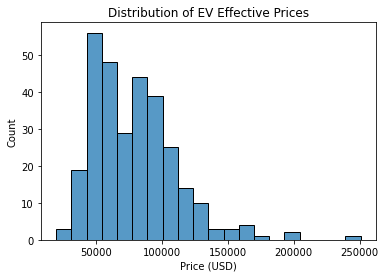

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=df_web_cleaned, x="Effective Price (USD)", bins=20)
plt.title("Distribution of EV Effective Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.show()

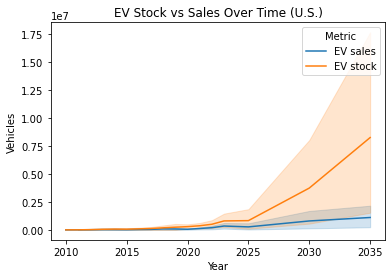

In [6]:
df_sales_stock = df_flat_cleaned[df_flat_cleaned['region'].str.lower() == 'usa']

sns.lineplot(data=df_sales_stock, x='year', y='value', hue='parameter')
plt.title("EV Stock vs Sales Over Time (U.S.)")
plt.xlabel("Year")
plt.ylabel("Vehicles")
plt.legend(title="Metric")
plt.show()

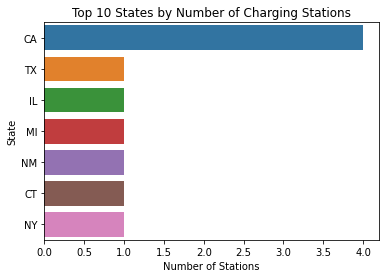

In [7]:
station_counts = df_api_cleaned['State'].value_counts().head(10).reset_index()
station_counts.columns = ['State', 'Count']

sns.barplot(data=station_counts, x='Count', y='State')
plt.title("Top 10 States by Number of Charging Stations")
plt.xlabel("Number of Stations")
plt.ylabel("State")
plt.show()

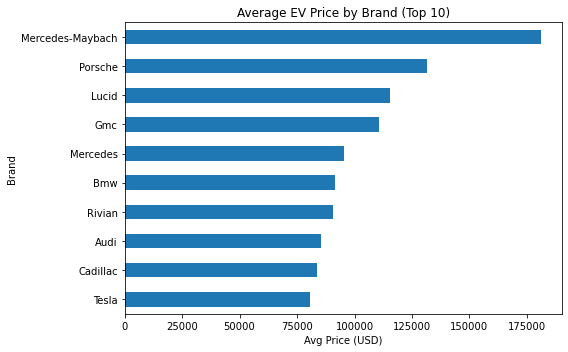

In [8]:
# Extract the brand as the first word of the Car Model field
df_web_cleaned['Brand'] = df_web_cleaned['Car Model'].str.split().str[1]
# (First word is usually the model year, e.g. "2024" - second word is the brand)

avg_price_by_brand = (
    df_web_cleaned.groupby('Brand')['Effective Price (USD)']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
avg_price_by_brand.plot(kind='barh')
plt.title("Average EV Price by Brand (Top 10)")
plt.xlabel("Avg Price (USD)")
plt.ylabel("Brand")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

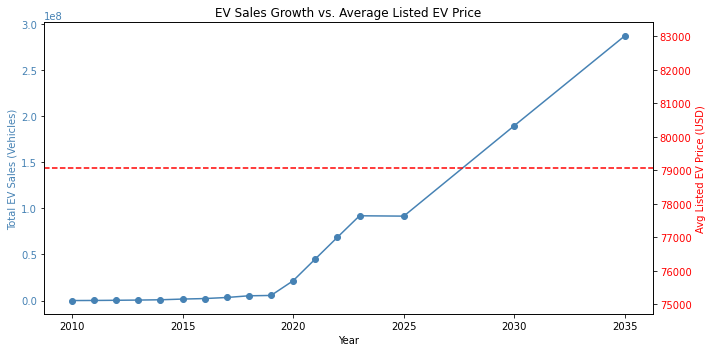

In [9]:
avg_price = df_web_cleaned['Effective Price (USD)'].mean()
total_sales = (
    df_flat_cleaned[df_flat_cleaned['parameter'] == 'EV sales']
    .groupby('year')['value'].sum().reset_index()
)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(total_sales['year'], total_sales['value'], marker='o', color='steelblue', label='EV Sales')
ax1.set_xlabel("Year")
ax1.set_ylabel("Total EV Sales (Vehicles)", color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.axhline(avg_price, color='red', linestyle='--', label='Avg Listed EV Price')
ax2.set_ylabel("Avg Listed EV Price (USD)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("EV Sales Growth vs. Average Listed EV Price")
fig.tight_layout()
plt.show()

In [10]:
# Summary of Findings:

# 1. EV Sales & Stock (ev_flat): U.S. EV stock and sales trend upward, with stock growing faster than annual sales.

# 2. EV Listing Prices (ev_web): Prices are right-skewed, mostly clustering between $50k-$100k.

# 3. Charging Infrastructure (ev_api): Stations are concentrated in a few states, led by California.

# 4. Data Limitation: The three sources don't share a common key, so each was analyzed independently rather than joined.